# <center style="font-family: consolas; font-size: 32px; font-weight: bold;">  Hands-On LangChain for LLM Applications Development: Vector Database & Text Embeddings </center>
***


Once you have loaded your documents and split them up into small, semantically meaningful chunks, it’s time to put these chunks into an index, whereby we can easily retrieve them when it comes time to answer questions about this corpus of data. 

To do so we will use embeddings and vector stores a sophisticated approach that not only facilitates the storage of information but also transforms the way we answer questions about our data corpus. 

In this notebook, we will first explore what is text embeddings and vector stores. Then we will cover how to create and store text Embeddings in vector stores with LangChain. We will conclude this notebook with some failure cases of this method.

#### <a id="top"></a>
# <div style="box-shadow: rgb(60, 121, 245) 0px 0px 0px 3px inset, rgb(255, 255, 255) 10px -10px 0px -3px, rgb(31, 193, 27) 10px -10px, rgb(255, 255, 255) 20px -20px 0px -3px, rgb(255, 217, 19) 20px -20px, rgb(255, 255, 255) 30px -30px 0px -3px, rgb(255, 156, 85) 30px -30px, rgb(255, 255, 255) 40px -40px 0px -3px, rgb(255, 85, 85) 40px -40px; padding:20px; margin-right: 40px; font-size:30px; font-family: consolas; text-align:center; display:fill; border-radius:15px; color:rgb(60, 121, 245);"><b>Table of contents</b></div>

<div style="background-color: rgba(60, 121, 245, 0.03); padding:30px; font-size:15px; font-family: consolas;">
<ul>
    <li><a href="#1" target="_self" rel=" noreferrer nofollow">1. What are Text Embeddings? </a></li> 
    <li><a href="#2" target="_self" rel=" noreferrer nofollow">2. What is a Vector Database? </a></li> 
    <li><a href="#3" target="_self" rel=" noreferrer nofollow">3. Creating Text Embeddings with LangChain </a></li> 
    <li><a href="#4" target="_self" rel=" noreferrer nofollow">4. Store Text Embeddings In Vector Database with LangChain </a></li>
    <li><a href="#5" target="_self" rel=" noreferrer nofollow">5. Failure Cases (doc / docx) </a></li>    
</ul>
</div>

***

<a id="1"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 1. What are Text Embeddings? </b></div>


They take a piece of text, and they create a numerical representation of that text. Text with similar content will have similar vectors in this numeric space. What that means is we can then compare those vectors and find pieces of text that are similar. So, in the example below, we can see that the two sentences about pets are very similar, while a sentence about a pet and a sentence about a car are not very similar.

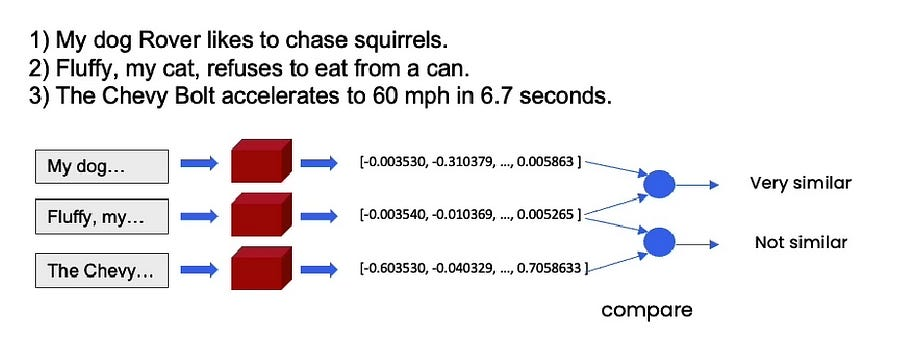

There are several reasons why text embeddings are essential in natural language processing (NLP) and machine learning applications:

**Semantic Similarity and Distance**: Text embeddings enable us to measure the semantic similarity between words, phrases, or documents. In the vector space, similar meanings are represented by vectors that are closer to each other, while dissimilar meanings are represented by vectors that are farther apart. This makes it easier to compare and find relationships between words.

**Machine Learning Models**: Text embeddings are crucial for training machine learning models on textual data. Traditional machine learning models and deep learning models often require a fixed-size input, and text embeddings provide a way to represent variable-length textual data in a fixed-size vector.

**Transfer Learning**: Text embeddings facilitate transfer learning, where a model pre-trained on a large dataset can be fine-tuned on a smaller, domain-specific dataset. Pre-trained embeddings capture general semantic information from the large dataset, making it easier for the model to learn from a smaller dataset without starting from scratch.

**Dimensionality Reduction**: Text embeddings often have a lower-dimensional representation compared to one-hot encoded vectors. This reduces the dimensionality of the input space, which can be beneficial for computational efficiency and can help prevent the “curse of dimensionality.”

**Improved Generalization**: Embeddings can capture semantic relationships and context, which helps models generalize better to unseen data. By representing words in a meaningful way, embeddings enhance a model’s ability to understand and learn patterns from the input data.

**Word Similarity and Analogies**: Text embeddings can capture relationships between words, enabling operations like word similarity and analogies. For example, by subtracting the vector for “king” from “queen” and adding the result to “man,” you might get a vector close to “woman,” showcasing the ability to perform analogical reasoning.

Popular techniques for generating text embeddings include Word2Vec, GloVe (Global Vectors for Word Representation), FastText, and more recently, contextual embeddings such as BERT (Bidirectional Encoder Representations from Transformers) and GPT (Generative Pre-trained Transformer).

<a id="2"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 2. What is a Vector Database? </b></div>

A vector store is a database where you can easily look up similar vectors later on. This will become useful when we’re trying to find documents that are relevant to the question at hand. We can then take the question at hand, create an embedding, and then do comparisons to all the different vectors in the vector store, and then pick the n most similar. We then take those n most similar chunks and pass them along with the question into an LLM, and get back an answer.

Conventional databases struggle to cope with the complexity and scale of vector data, which can hinder the extraction of valuable insights and real-time analysis. However, a solution to this problem lies in the adoption of vector databases, specially engineered to handle this type of data efficiently. By leveraging vector databases, organizations can unlock the full potential of their data, enjoying improved performance, scalability, and flexibility.

To understand how vector databases work let’s take an example of a chatbot such as chatGPT or bard which are based on LLM. These models have large volumes of data with a lot of content. Here is how vector database is used within the context of this application:

1. The user will input your query into the application.

2. Then the query is inserted into the embedding model, which generates vector embeddings according to the content we wish to index.

3. The vector embedding then moves into the vector database, regarding the content that the embedding was made from.

4. The vector database produces an output and sends it back to the user as a query result.

The diagram below gives us a better understanding of the role of vector databases in this type of application:

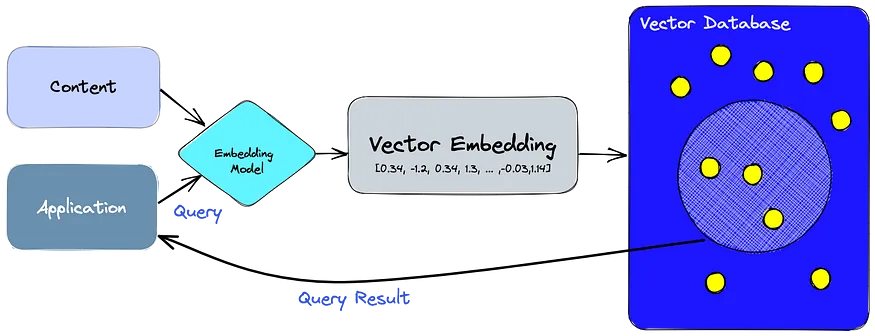

In traditional databases strings, numbers, etc are stored in rows and columns. Therefore when we query a certain row or column we are querying a row or column that matches the query statement. On the other hand, vector databases work with vectors rather than strings, numbers, etc. Vector databases also apply a similarity metric which is used to help find a vector most similar to the query.

In the vector database, the similarity search is done using different algorithms which all aid in the Approximate Nearest Neighbor (ANN) search. This is done via hashing, graph-based search, or quantization which are assembled into a pipeline to retrieve neighbors of a queried vector. The results are based on how close or approximate it is to the query, therefore the main elements that are considered are accuracy and speed. If the query output is slow, the more accurate the result.

<a id="3"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 3.Creating Text Embeddings with LangChain  </b></div>

To start, we’ll once again set the appropriate environment variables.

In [1]:
!pip install -r requirements.txt
!pip install -r requirements.txt
!pip install pypdf -q
!pip install yt_dlp -q
!pip install pydub -q
!pip install unstructured -q
!pip install docx2txt -q
!pip install openai -q
!pip install python-dotenv -q
!pip install xlrd -q
!pip install tiktoken -q
!pip install chromadb

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-cv 0.9.0 requires keras-core, which is not installed.
keras-nlp 0.12.1 requires keras-core, which is not installed.
tensorflow-decision-forests 1.8.1 requires wurlitzer, which is not installed.
apache-beam 2.46.0 requires dill<0.3.2,>=0.3.1.1, but you have dill 0.3.8 which is incompatible.
apache-beam 2.46.0 requires numpy<1.25.0,>=1.14.3, but you have numpy 1.26.4 which is incompatible.
apache-beam 2.46.0 requires pyarrow<10.0.0,>=3.0.0, but you have pyarrow 16.1.0 which is incompatible.
google-cloud-bigquery 2.34.4 requires packaging<22.0dev,>=14.3, but you have packaging 24.1 which is incompatible.
jupyterlab 4.2.1 requires jupyter-lsp>=2.0.0, but you have jupyter-lsp 1.5.1 which is incompatible.
jupyterlab-lsp 5.1.0 requires jupyter-lsp>=2.0.0, but you have jupyter-lsp 1.5.1 which is incompatible.
libpys

In [2]:
from openai import OpenAI
import openai
import os
import numpy as np
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
openai.api_key = user_secrets.get_secret("openai_api")
client = OpenAI(
    # This is the default and can be omitted
    api_key=openai.api_key,
)

llm_model = "gpt-3.5-turbo"

We will use OpenAI to create the text embeddings. Before jumping into a real-world example:

In [3]:
from langchain_openai import OpenAIEmbeddings
embedding = OpenAIEmbeddings(openai_api_key=openai.api_key)

/opt/conda/lib/python3.10/site-packages/langchain_core/_api/deprecation.py:139: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 0.3.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import OpenAIEmbeddings`.
  warn_deprecated(


Let’s try it out with a few toy test cases just to get a sense of what’s going on underneath the hood. We will use the same example sentences we used before where the first two are very similar and the third one is unrelated:

In [4]:
sentence1 = "My dog Rover likes to chase squirrels"
sentence2 = "Fluffy my cat, refuses to eat from a can"
sentence3 = "The chevy bolt accelerates to 60 mph in 6.7 seconds"

We can then use the embedding class to create an embedding for each sentence. 



In [5]:
embedding1 = embedding.embed_query(sentence1)
embedding2 = embedding.embed_query(sentence2)
embedding3 = embedding.embed_query(sentence3)

We can then use NumPy to compare them and see which ones are most similar. We expect that the first two sentences should be very similar, and then the first and second compared to the third shouldn’t be nearly as similar. We’ll use a dot product to compare the two embeddings.

In [6]:
print('The similarity between sentences one and two is' , np.dot(embedding1, embedding2))
print('The similarity between sentences one and three is' , np.dot(embedding1, embedding3))
print('The similarity between sentences two and three' , np.dot(embedding2, embedding3))

The similarity between sentences one and two is 0.7994217224486891
The similarity between sentences one and three is 0.7492779153935134
The similarity between sentences two and three 0.6991800057325509


Here we can see that the first two embeddings have a pretty high score of 0.8. If we compare the first embedding to the third one, we can see that it’s lower at 0.75. And if we compare the second to the third the result is 0.69, which is also lower than the first two. 

Let’s now work with a real-world example. We are going to be working with the CS229 lectures as our main set of documents. First, we will load a few of them here. Notice that we’re going to duplicate the first lecture. This is to simulate some dirty data.



In [7]:
from langchain_community.document_loaders import PyPDFLoader

# Load PDF
loaders = [
    # Duplicate documents on purpose - messy data
    PyPDFLoader("/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf"),
    PyPDFLoader("/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf"),
    PyPDFLoader("/kaggle/input/machine-learning-lectures/MachineLearning-Lecture02.pdf"),
    PyPDFLoader("/kaggle/input/machine-learning-lectures/MachineLearning-Lecture03.pdf")
]
docs = []
for loader in loaders:
    docs.extend(loader.load())

After the documents are loaded, we can then use the recursive character text splitter to create chunks. We can see that we’ve now created over 200 different chunks:

In [8]:
# Split
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 150
)

splits = text_splitter.split_documents(docs)
len(splits)

209

Now it is time to create embeddings for all the chunks of the PDFs and then store them in a vector store. The vector store that we’ll use for this lesson is the Chroma vector database.

<a id="4"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 4.Store Text Embeddings In Vector Database with LangChain  </b></div>


LangChain has integrations with over 30 different vector stores. We will use the Chroma database because it’s lightweight and in memory, which makes it very easy to get up and start with. 

Other vector stores offer hosted solutions, which can be useful when you’re trying to persist large amounts of data or persist it in cloud storage somewhere. We will save this vector store so that we can use it in future articles. 

Let’s create a variable called persist directory, which we will use later on, and also we will make sure that nothing is there already. If there’s data there already, it can throw things off and we don’t want that to happen.

In [9]:
from langchain_community.vectorstores import Chroma
persist_directory = 'docs/chroma/'
!rm -rf ./docs/chroma  # remove old database files if any

Let’s now create the vector store. We call Chroma from documents, passing in splits, and these are the splits that we created earlier, passing in embedding. This is the open AI embedding model and then passing in the persist directory, which is a Chroma-specific keyword argument that allows us to save the directory to disk.



In [10]:
vectordb = Chroma.from_documents(
    documents=splits,
    embedding=embedding,
    persist_directory=persist_directory
)

print(vectordb._collection.count())

209


we can see that the collection count is 209, which is the same as the number of splits that we had before.

Let’s think of a question that we can ask of this data. We know that this is about a class lecture. So, let’s ask what are the names of the TAs and their emails so that we can ask for help if we need it. We’re going to use the similarity search method, and we’re going to pass in the question, and then we’ll also pass in K equals three. This specifies the number of documents that we want to return. So, if we run that and look at the length of the documents, we can see that it’s three as we specified.

In [11]:
question = "What are the names and emails of the course TA?"
docs = vectordb.similarity_search(question,k=3)
len(docs)

3

If we take a look at the content of the first document, we can see that it is in fact about an email address, cs229-qa.cs.stanford.edu. And this is the email that we can send questions to and is read by all the TAs. However, their names are not available so they are not in the returned answers.

In [12]:
docs[0].page_content

"cs229-qa@cs.stanford.edu. This goes to an acc ount that's read by all the TAs and me. So \nrather than sending us email individually, if you send email to this account, it will \nactually let us get back to you maximally quickly with answers to your questions.  \nIf you're asking questions about homework probl ems, please say in the subject line which \nassignment and which question the email refers to, since that will also help us to route \nyour question to the appropriate TA or to me  appropriately and get the response back to \nyou quickly.  \nLet's see. Skipping ahead — let's see — for homework, one midterm, one open and term \nproject. Notice on the honor code. So one thi ng that I think will help you to succeed and \ndo well in this class and even help you to enjoy this cla ss more is if you form a study \ngroup.  \nSo start looking around where you' re sitting now or at the end of class today, mingle a \nlittle bit and get to know your classmates. I strongly encourage you to f

<a id="5"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 5.Failure Cases  </b></div>



Let's go through a few edge cases and show where this can fail. Let’s try a new question. What did they say about Python? Let’s run this specifying K equals five and get back some results.

In [13]:
question = "what did they say about matlab?"
docs = vectordb.similarity_search(question,k=5)


Let's take a look at the first two results, we can see that they’re identical.



In [14]:
docs[0]


Document(metadata={'page': 8, 'source': '/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf'}, page_content='those homeworks will be done in either MATLA B or in Octave, which is sort of — I \nknow some people call it a free ve rsion of MATLAB, which it sort  of is, sort of isn\'t.  \nSo I guess for those of you that haven\'t s een MATLAB before, and I know most of you \nhave, MATLAB is I guess part of the programming language that makes it very easy to write codes using matrices, to write code for numerical routines, to move data around, to \nplot data. And it\'s sort of an extremely easy to  learn tool to use for implementing a lot of \nlearning algorithms.  \nAnd in case some of you want to work on your  own home computer or something if you \ndon\'t have a MATLAB license, for the purposes of  this class, there\'s also — [inaudible] \nwrite that down [inaudible] MATLAB — there\' s also a software package called Octave \nthat you can download for free off the Inter

In [15]:
docs[1]

Document(metadata={'page': 8, 'source': '/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf'}, page_content='those homeworks will be done in either MATLA B or in Octave, which is sort of — I \nknow some people call it a free ve rsion of MATLAB, which it sort  of is, sort of isn\'t.  \nSo I guess for those of you that haven\'t s een MATLAB before, and I know most of you \nhave, MATLAB is I guess part of the programming language that makes it very easy to write codes using matrices, to write code for numerical routines, to move data around, to \nplot data. And it\'s sort of an extremely easy to  learn tool to use for implementing a lot of \nlearning algorithms.  \nAnd in case some of you want to work on your  own home computer or something if you \ndon\'t have a MATLAB license, for the purposes of  this class, there\'s also — [inaudible] \nwrite that down [inaudible] MATLAB — there\' s also a software package called Octave \nthat you can download for free off the Inter

The reason we got two identical answers is that we loaded in the PDFs on purpose a duplicate entry. This is bad because we’ve got the same information in two different chunks and we’re going to be passing both of these chunks to the language model down the line. There’s no real value in the second piece of information and it would be much better if there was a different distinct chunk that the language model could learn from.

Another type of failure mode can also happen when we specify a certain source to answer our questions. Let’s take a look at the question, what did they say about supervised learning in the second lecture? When we get the docs for this, intuitively we would expect them to all be part of the second lecture. We can check this because we have information in the metadata about what lectures they came from. So, let’s loop over all the documents and print out the metadata.



In [16]:
question = "what did they say about supervised machine learning in the third lecture?"
docs = vectordb.similarity_search(question,k=5)
for doc in docs:
    print(doc.metadata)

{'page': 8, 'source': '/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf'}
{'page': 8, 'source': '/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf'}
{'page': 8, 'source': '/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf'}
{'page': 8, 'source': '/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf'}
{'page': 2, 'source': '/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf'}


As you can see there’s actually a combination of results, some from the third lecture, some from the second lecture, and some from the first. The intuition about why this is failing is that we want documents from only the second lecture as a piece of structured information, but we’re just doing a semantic lookup based on embeddings where it creates an embedding for the whole sentence and it’s probably a bit more focused on supervised learning. Therefore, we’re getting results that are probably pretty relevant to regression and so if we take a look at the fifth doc, the one that comes from the first lecture, we can see that it does mention supervised learning.

In [17]:
print(docs[4].page_content)


So in this class, we've tried to convey to you a broad set of principl es and tools that will 
be useful for doing many, many things. And ev ery time I teach this class, I can actually 
very confidently say that af ter December, no matter what yo u're going to do after this 
December when you've sort of completed this  class, you'll find the things you learn in 
this class very useful, and these things will be useful pretty much no matter what you end 
up doing later in your life.  
So I have more logistics to go over later, but let's say a few more words about machine 
learning. I feel that machine learning grew out of  early work in AI, early work in artificial 
intelligence. And over the last — I wanna say last 15 or last 20 years or so, it's been viewed as a sort of growing new capability for computers. And in particular, it turns out 
that there are many programs or there are many applications that you can't program by 
hand.  
For example, if you want to get a computer to read ha

So, it’s picking up on that, but it’s not picking up on the fact that it’s only supposed to be querying documents from the second lecture because again, that’s a piece of structured information that isn’t perfectly captured in this semantic embedding that we’ve created. In the next notebook, we will cover how to address those failure modes.



# <div style="box-shadow: rgba(240, 46, 170, 0.4) -5px 5px inset, rgba(240, 46, 170, 0.3) -10px 10px inset, rgba(240, 46, 170, 0.2) -15px 15px inset, rgba(240, 46, 170, 0.1) -20px 20px inset, rgba(240, 46, 170, 0.05) -25px 25px inset; padding:20px; font-size:30px; font-family: consolas; display:fill; border-radius:15px; color: rgba(240, 46, 170, 0.7)"> <b> ༼⁠ ⁠つ⁠ ⁠◕⁠‿⁠◕⁠ ⁠༽⁠つ Thank You!</b></div>

<p style="font-family:verdana; color:rgb(34, 34, 34); font-family: consolas; font-size: 16px;"> 💌 Thank you for taking the time to read through my notebook. I hope you found it interesting and informative. If you have any feedback or suggestions for improvement, please don't hesitate to let me know in the comments. <br><br> 🚀 If you liked this notebook, please consider upvoting it so that others can discover it too. Your support means a lot to me, and it helps to motivate me to create more content in the future. <br><br> ❤️ Once again, thank you for your support, and I hope to see you again soon!</p>